# Week 1: Data Exploration

============================================================

IDX Exchange — Data Science Internship

Week 1: Data Exploration

Author: Zachary Blehm

============================================================

Summary:



*   Load & Initial Filtering of Data
*   Investigate and Remove Duplicates
*   Filter to Living Area, Lot Size (sqft), Number of bedrooms, Number of bathrooms (Primary Predictors) + ClosePrice (Target)
*   Investigation of Distribution and Outlier Filtering Techniques
* Predictor and Target Visualizations





In [35]:
# Imports and File Loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import files

# Use 13 months of data for training
# Hold out 202603 & 202604 for testing
data_dir = Path('data')
training_files = [
    'CRMLSSold202502.csv',
    'CRMLSSold202503.csv',
    'CRMLSSold202504.csv',
    'CRMLSSold202505.csv',
    'CRMLSSold202506.csv',
    'CRMLSSold202507.csv',
    'CRMLSSold202508.csv',
    'CRMLSSold202509.csv',
    'CRMLSSold202510.csv',
    'CRMLSSold202511.csv',
    'CRMLSSold202512.csv',
    'CRMLSSold202601.csv',
    'CRMLSSold202602.csv',
]

dfs = [pd.read_csv(f, dtype=str) for f in training_files]
df = pd.concat(dfs, ignore_index=True)
print('Combined training shape:', df.shape)

Combined training shape: (276863, 80)


# Initial Filtering of the Data

Filter the data for "Residential" and "SingleFamilyResidence" per the task of predicing home prices.

In [36]:
# Filter the data based on the desired type and subtype

df = df[
    (df['PropertyType'] == 'Residential') &
    (df['PropertySubType'] == 'SingleFamilyResidence')
].copy()
print('After filter:', df.shape)

After filter: (138515, 80)


In [37]:
# Basic DataFrame info for later reference
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138515 entries, 2 to 276851
Data columns (total 80 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   BuyerAgentAOR                 137625 non-null  object
 1   ListAgentAOR                  138496 non-null  object
 2   Flooring                      89077 non-null   object
 3   ViewYN                        125935 non-null  object
 4   WaterfrontYN                  73 non-null      object
 5   BasementYN                    3348 non-null    object
 6   PoolPrivateYN                 127886 non-null  object
 7   OriginalListPrice             138230 non-null  object
 8   ListingKey                    138515 non-null  object
 9   ListAgentEmail                138065 non-null  object
 10  CloseDate                     138515 non-null  object
 11  ClosePrice                    138515 non-null  object
 12  ListAgentFirstName            137598 non-null  object
 13  List

Importantly ClosePrice and CloseDate do not have any null values.

# Investigate Duplicates

In [38]:
# Check the numner of unique listing (investigate duplicates)
print('Total rows:', len(df))
print('Uniquie keys:', df['ListingKey'].nunique())
print('Number of rows with duplicate keys:', df['ListingKey'].duplicated().sum())

print('Number of rows that are complete duplicates:', df.duplicated().sum())

Total rows: 138515
Uniquie keys: 138414
Number of rows with duplicate keys: 101
Number of rows that are complete duplicates: 6


The complete duplicates can be safely removed since all columns are identical, representing true duplicates.

In [39]:
# Remove the complete duplicates
df_2 = df.drop_duplicates().copy()

print('Original rows:', len(df))
print('Rows after removing exact duplicates:', len(df_2))
print('Rows removed:', len(df) - len(df_2))

Original rows: 138515
Rows after removing exact duplicates: 138509
Rows removed: 6


In [40]:
# Get the ListingKey of the remaining duplicates
duplicate_ids = (
    df_2.loc[df_2['ListingKey'].duplicated(keep=False), 'ListingKey']
    .unique()
)

# Full information for the remaining duplicates (difference column by column)
for house_id in duplicate_ids:
    group = df_2[df_2['ListingKey'] == house_id]

    # Find columns with different values
    different_columns = group.columns[
        group.nunique(dropna=False) > 1
    ].tolist()

    print(f"\n--- ID: {house_id} ---")
    print('Different columns:', different_columns)

    display(group[['ListingKey'] + different_columns])


--- ID: 1103102163 ---
Different columns: ['CloseDate', 'ContractStatusChangeDate']


,ListingKey,CloseDate,ContractStatusChangeDate
4186,1103102163,2025-02-04,2025-02-04
31021,1103102163,2025-03-04,2025-03-04



--- ID: 1100177672 ---
Different columns: ['CloseDate', 'BuyerOfficeName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerOfficeAOR', 'ContractStatusChangeDate', 'PurchaseContractDate']


,ListingKey,CloseDate,BuyerOfficeName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,BuyerOfficeAOR,ContractStatusChangeDate,PurchaseContractDate
10937,1100177672,2025-02-21,Luxury Collective,CV39190,Mario,Ayoub,CitrusValley,2025-02-21,2025-01-15
35020,1100177672,2025-03-20,The Mortgage Pros Funding,IGCASTDIE,Diego,Gonzalez Castillo,TheInlandGateway,2025-03-20,2025-03-03



--- ID: 1097519251 ---
Different columns: ['CloseDate', 'ClosePrice', 'ContractStatusChangeDate']


...

,ListingKey,BuyerAgentAOR,CloseDate,Latitude,Longitude,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,ContractStatusChangeDate,Stories,MainLevelBedrooms,OriginatingSystemName,OriginatingSystemSubName
247517,1147138715,InlandValleys,2026-01-20,33.988783000000005,-117.42341200000001,1987.0,5839.0,2.0,3.0,2026-01-20,1.0,1.0,NaN,NaN
270089,1147138715,Downey,2026-02-05,33.988783,-117.423412,1987,5839,2,3,2026-02-05,1,1,CRMLS,CRMLS_CRM



--- ID: 1144635053 ---
Different columns: ['CloseDate', 'ClosePrice', 'Latitude', 'Longitude', 'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'BedroomsTotal', 'ContractStatusChangeDate', 'OriginatingSystemName', 'OriginatingSystemSubName']


,ListingKey,CloseDate,ClosePrice,Latitude,Longitude,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,ContractStatusChangeDate,OriginatingSystemName,OriginatingSystemSubName
251595,1144635053,2026-01-29,1578331.0,37.0032137,-121.57792140000002,2025.0,7363.0,5.0,5.0,2026-01-29,NaN,NaN
272422,1144635053,2026-02-12,1714623.0,NaN,NaN,2025,7363,5,5,2026-02-12,CRMLS,CRMLS_MLSL



--- ID: 1118859284 ---
Different columns: ['BuyerAgentAOR', 'CloseDate', 'ClosePrice', 'Longitude', 'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'BedroomsTotal', 'ContractStatusChangeDate', 'Stories', 'MainLevelBedrooms', 'OriginatingSystemName', 'OriginatingSystemSubName']


,ListingKey,BuyerAgentAOR,CloseDate,ClosePrice,Longitude,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,ContractStatusChangeDate,Stories,MainLevelBedrooms,OriginatingSystemName,OriginatingSystemSubName
256610,1118859284,TriCounties,2026-01-16,875000.0,-117.54245300000001,2017.0,5599.0,4.0,5.0,2026-01-16,1.0,5.0,NaN,NaN
275850,1118859284,TheInlandGateway,2026-02-06,874400.0,-117.542453,2017,5599,4,5,2026-02-06,1,5,CRMLS,CRMLS_CRM


### Comments On Remaining Duplicates

We see that the remaining duplicate ListingKey rows all differ in the CloseDate and ContractStatusChangeDate fields. Many of these duplicates differ in other fields as well. We observe four general categories based on four important categories (CloseDate, ContractStatusChangeDate, ClosePrice and PurchaseContractDate) but note that within each category other fields (e.g. fields related to Buyer Agent) may or may not differ:


*   Differing CloseDate and ContractStatusChangeDate. In this case we keep the duplicate with the most recent CloseDate and remove earlier the earlier duplicate(s). This decision is based on identical ClosePrice so the information provided in learning the target is identical since ContractStatusChangeDate is not a field used for prediction.
*   Differing CloseDate, ContractStatusChangeDate and PurchaseContractDate. In this case we keep the duplicate with the most recent CloseDate and remove earlier the earlier duplicate(s). This decision is based on identical ClosePrice so the information provided in learning the target is identical since neither ContractStatusChangeDate and PurchaseContractDate are used for prediction.
*   Differing CloseDate, ContractStatusChangeDate and ClosePrice differ. In this case we keep the row with the most recent CloseDate, interpreting the repeated ListingKey as indicating that the initial sale, seemed to be finalized but then for some reason was not actually completed.
*   Differing CloseDate, ContractStatusChangeDate, ClosePrice and PurchaseContractDate differ. Similar to the previous case we keep the we keep the row with the most recent CloseDate, interpreting the repeated ListingKey as indicating that the initial sale, seemed to be finalized but then for some reason was not actually completed.

It is important to remember that of the columns discussed above only ClosePrice will be kept (as the target). The other columns such as CloseDate, are data that only exists for a listing, not any home in general, and is therefore not used as a predictor in the models.





In [41]:
# Keep the duplicate "ListingKey" with the most recent "CloseDate"
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

df = (
    df.sort_values("CloseDate", ascending=False)
      .drop_duplicates(subset="ListingKey", keep="first")
)

# Confirm no duplicates left in the DataFrame
print('Total rows:', len(df))
print('Uniquie keys:', df['ListingKey'].nunique())
print('Number of rows with duplicate keys:', df['ListingKey'].duplicated().sum())

Total rows: 138414
Uniquie keys: 138414
Number of rows with duplicate keys: 0


### Living Area Data Integrity Issue

The data set contains the important "LivingArea" field. The Trestle documnetation indicates a "LivingAreaUnits" field as well. The presence of the latter implies that the former is not standardized. However the imported data does not contain the "LivingAreaUnits" field, so we are unable to standardize. As an alternative we will investigate the distrubution below and develop a scheme to manually remove outliers.

# Filter to the 4 Primary Columns + Target (ClosePrice).

In [67]:
numeric_cols = [
    'ClosePrice', 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea',
    'LotSizeSquareFeet'
]


for col in numeric_cols:
  if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


# Keep primary columns being considered and CloseDate for time series analysis
df_primary_columns = df[numeric_cols + ['CloseDate']]


# Measure completeness for the target and main features.
missing_summary = pd.DataFrame({
    "missing_rows": df_primary_columns.isna().sum(),
    "missing_percent": df_primary_columns.isna().mean().mul(100),
}).sort_values("missing_percent", ascending=False)

display(missing_summary)

display(df_primary_columns.describe())

,missing_rows,missing_percent
LotSizeSquareFeet,2405,1.737541
LivingArea,79,0.057075
BathroomsTotalInteger,18,0.013004
ClosePrice,0,0.000000
BedroomsTotal,0,0.000000
CloseDate,0,0.000000


,ClosePrice,BedroomsTotal,BathroomsTotalInteger,LivingArea,LotSizeSquareFeet,CloseDate
count,1.384140e+05,138414.000000,138396.000000,138335.000000,1.360090e+05,138414
mean,1.316928e+06,3.488072,2.627865,2042.718834,3.728818e+05,2025-08-10 00:52:05.441067776
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,2025-02-01 00:00:00
25%,6.250000e+05,3.000000,2.000000,1383.000000,5.663000e+03,2025-05-09 00:00:00
50%,8.875000e+05,3.000000,2.000000,1814.000000,7.280000e+03,2025-08-07 00:00:00
75%,1.410000e+06,4.000000,3.000000,2434.000000,1.045400e+04,2025-11-07 00:00:00
max,9.895000e+08,45.000000,45.000000,56500.000000,2.087221e+09,2026-02-28 00:00:00
std,7.240871e+06,0.974314,1.135542,1038.696784,1.806489e+07,NaN


In [69]:
# Remove rows with non-positive ClosePrice
df_primary_columns = df_primary_columns[df_primary_columns['ClosePrice'] > 0].copy()
print('Number of rows with ClosePrice = 0: ', len(df) - len(df_primary_columns))

# Drop rows with missing values in columns required for the model
df_primary_columns = df_primary_columns.dropna().copy()

print('Number of rows with remaining null removed:', len(df) - len(df_primary_columns))

print(df_primary_columns.info())

Number of rows with ClosePrice = 0:  1
Number of rows with remaining null removed: 2502
<class 'pandas.core.frame.DataFrame'>
Index: 135912 entries, 260520 to 15790
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ClosePrice             135912 non-null  float64       
 1   BedroomsTotal          135912 non-null  float64       
 2   BathroomsTotalInteger  135912 non-null  float64       
 3   LivingArea             135912 non-null  float64       
 4   LotSizeSquareFeet      135912 non-null  float64       
 5   CloseDate              135912 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(5)
memory usage: 7.3 MB
None


There was a sole outlier with ClosePrice = 0.

In [44]:
# Examine the distributions
df_primary_columns.describe()

,ClosePrice,BedroomsTotal,BathroomsTotalInteger,LivingArea,LotSizeSquareFeet,CloseDate
count,1.359120e+05,135912.000000,135912.000000,135912.000000,1.359120e+05,135912
mean,1.312047e+06,3.487735,2.625324,2043.128156,3.597231e+05,2025-08-10 01:11:26.561892864
min,1.750000e+00,0.000000,0.000000,0.000000,0.000000e+00,2025-02-01 00:00:00
25%,6.200000e+05,3.000000,2.000000,1382.750000,5.663000e+03,2025-05-09 00:00:00
50%,8.850000e+05,3.000000,2.000000,1814.000000,7.280000e+03,2025-08-07 00:00:00
75%,1.410000e+06,4.000000,3.000000,2435.000000,1.045400e+04,2025-11-07 00:00:00
max,9.895000e+08,45.000000,45.000000,56500.000000,2.087221e+09,2026-02-28 00:00:00
std,7.293342e+06,0.974567,1.133370,1040.687159,1.738299e+07,NaN


The above summary of the primary columns presents some important data. We see concerning data for all of the minimum values and many of the maximum values as well. At this point we can see that the data still requires further cleaning.

# Plots of the Primary Columns Data

In [45]:
# Initial setup for the various plots

target = 'ClosePrice'

predictors_cont = [
    'LivingArea',
    'LotSizeSquareFeet'
]

predictors_discrete = [
    'BedroomsTotal',
    'BathroomsTotalInteger'
]

columns_cont = ['ClosePrice'] + predictors_cont

columns = ['ClosePrice'] + predictors_cont + predictors_discrete

sns.set_theme(style="whitegrid")

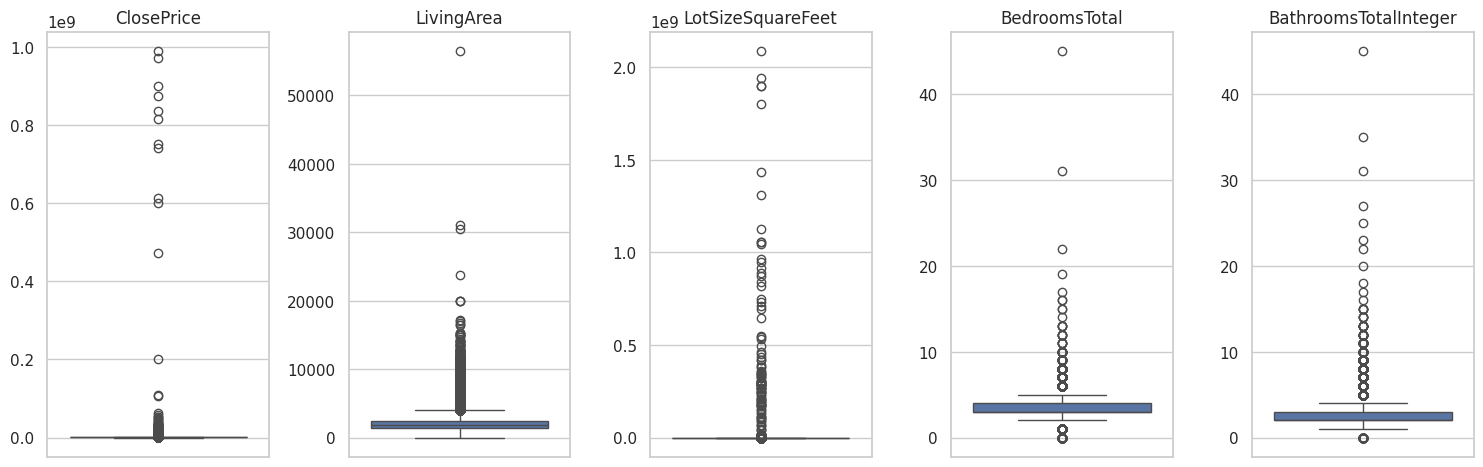

In [46]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for ax, col in zip(axes, columns):
    sns.boxplot(y=df_primary_columns[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## Filter the Data By +/- 3 Standard Deviations

We can see we have some outliers, which will affect the usefulness of the other plots if we continue to include them. We filter using +/- 3 standard deviations for each column and recheck the boxplots

In [47]:
# Calculate mean and standard deviation from the ORIGINAL data
means = df_primary_columns[columns].mean()
stds = df_primary_columns[columns].std()

# Define the fixed lower and upper bounds
lower_bounds = means - 3 * stds
upper_bounds = means + 3 * stds

# Create a mask: True if the row is within ±3 SD for EVERY column
mask = (
    df_primary_columns[columns].ge(lower_bounds) &
    df_primary_columns[columns].le(upper_bounds)
).all(axis=1)

# Create a new dataframe with the outliers removed
df_3sd = df_primary_columns[mask].copy()


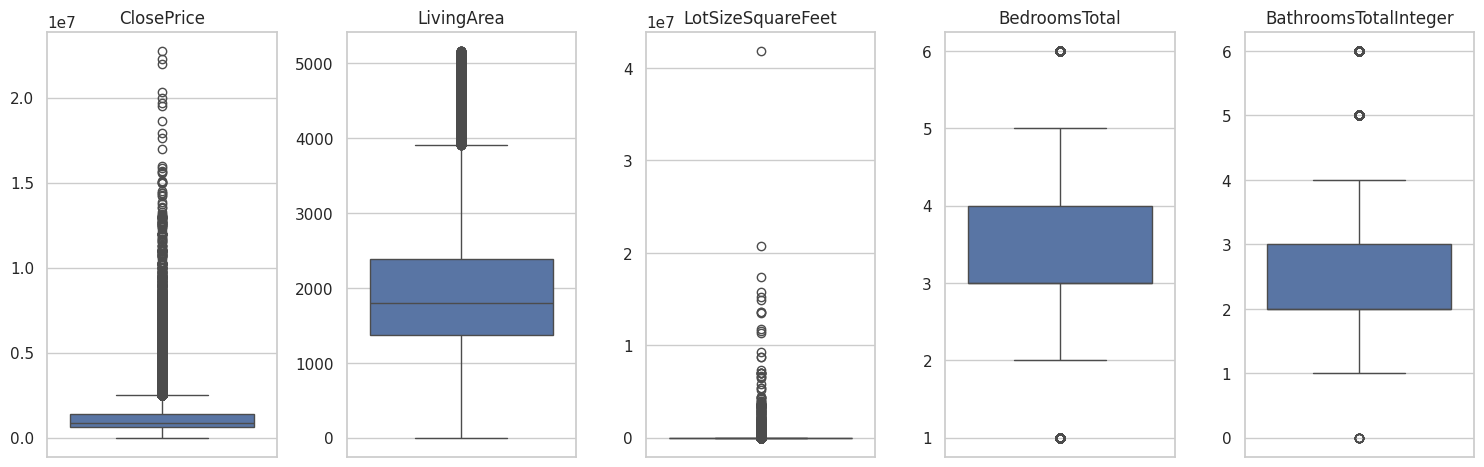

In [48]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for ax, col in zip(axes, columns):
    sns.boxplot(y=df_3sd[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

The boxplots look better, but additional cleaning is required. Specifcially:

*   We see that we still have listings with zero bathrooms.
*   The outliers in LotSizeSquareFeet are hiding the distribution of the majority of the data.
*   For LivingArea minimum of 0 need to be examined further.
*   For ClosePrice the minimum of 0 along with other unusually low values need to be examined further as well.





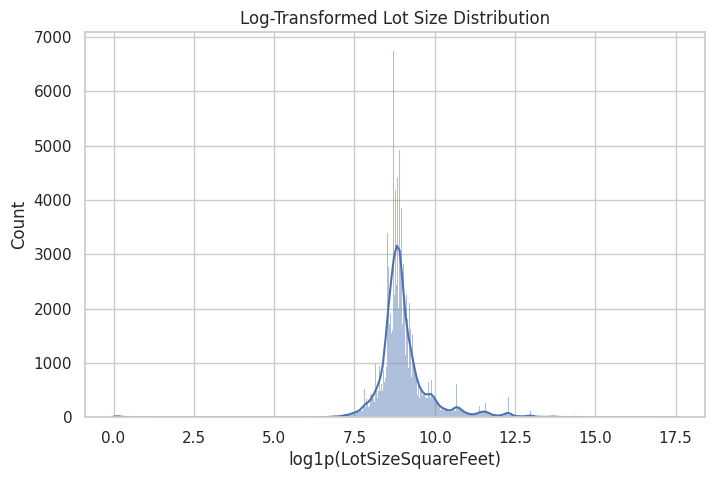

In [49]:
# Log plot of LotSizeSquareFeet to help visualize the distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    np.log1p(df_3sd["LotSizeSquareFeet"]),
    kde=True
)

plt.xlabel("log1p(LotSizeSquareFeet)")
plt.title("Log-Transformed Lot Size Distribution")

plt.show()

## Filter the Data By Percentiles

As an alternative to using standard deviations for filtering we also consider percentiles. Here we filter to 99% of observations, removing the lowest and highest 0.5%.

In [50]:
mask = pd.Series(True, index=df.index)

for col in columns:
    lower = df[col].quantile(0.005)
    upper = df[col].quantile(0.995)

    mask &= df[col].between(lower, upper)

df_percentile = df_primary_columns[mask].copy()

/tmp/ipykernel_659/2704574166.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_percentile = df_primary_columns[mask].copy()


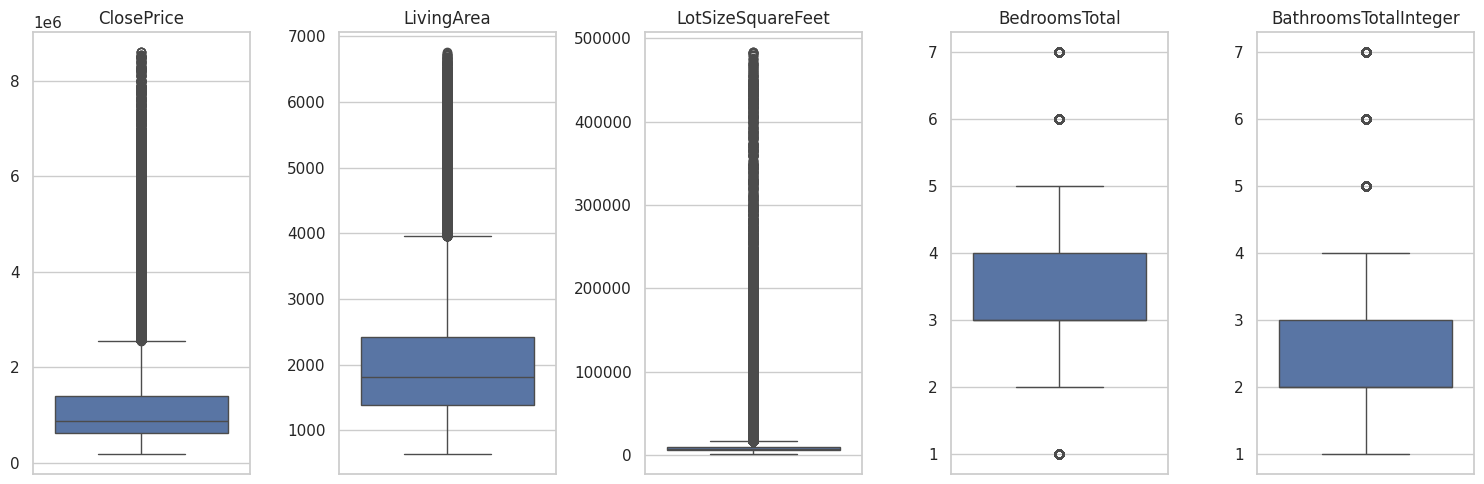

In [51]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for ax, col in zip(axes, columns):
    sns.boxplot(y=df_percentile[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

These boxplots look much better, so we proceed using the data filtered based on the middle 99% of the data.

In [52]:
df_percentile.describe()

,ClosePrice,BedroomsTotal,BathroomsTotalInteger,LivingArea,LotSizeSquareFeet,CloseDate
count,1.320220e+05,132022.000000,132022.000000,132022.000000,132022.000000,132022
mean,1.178310e+06,3.481496,2.592492,2007.313160,14963.416098,2025-08-09 18:22:35.010528768
min,1.870000e+05,1.000000,1.000000,640.000000,1307.000000,2025-02-01 00:00:00
25%,6.250000e+05,3.000000,2.000000,1390.000000,5663.000000,2025-05-09 00:00:00
50%,8.850000e+05,3.000000,2.000000,1813.000000,7247.000000,2025-08-07 00:00:00
75%,1.400000e+06,4.000000,3.000000,2418.000000,10200.000000,2025-11-06 00:00:00
max,8.600000e+06,7.000000,7.000000,6754.000000,483146.000000,2026-02-28 00:00:00
std,9.295149e+05,0.904463,1.005187,868.357842,35399.713084,NaN


We see that we have non-zero values for all minimum. Additionally the maximum values for bedrooms and bathrooms are more realistic. LostSizeSquareFeed still shows a large range of values, but this is understandable from the point of view of urban, small lots versus a rural property on a large piece of land.

### Histograms of Continous Variables

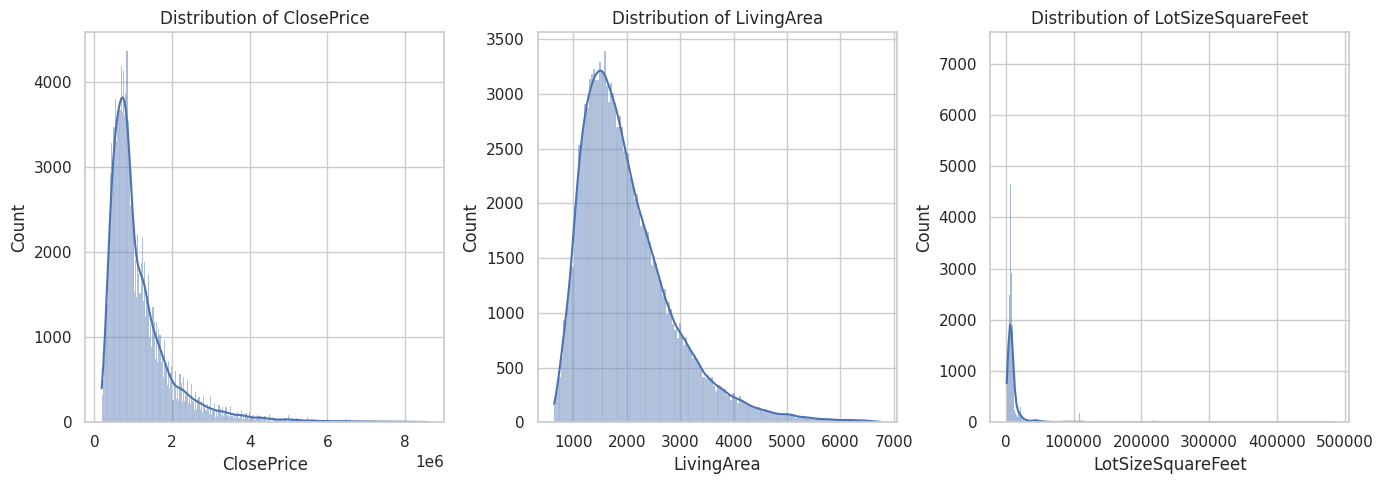

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, columns_cont):
    sns.histplot(
        data=df_percentile,
        x=col,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Unsurprisingly the distribution all show a right skew.

### Histograms of Discrete Variables

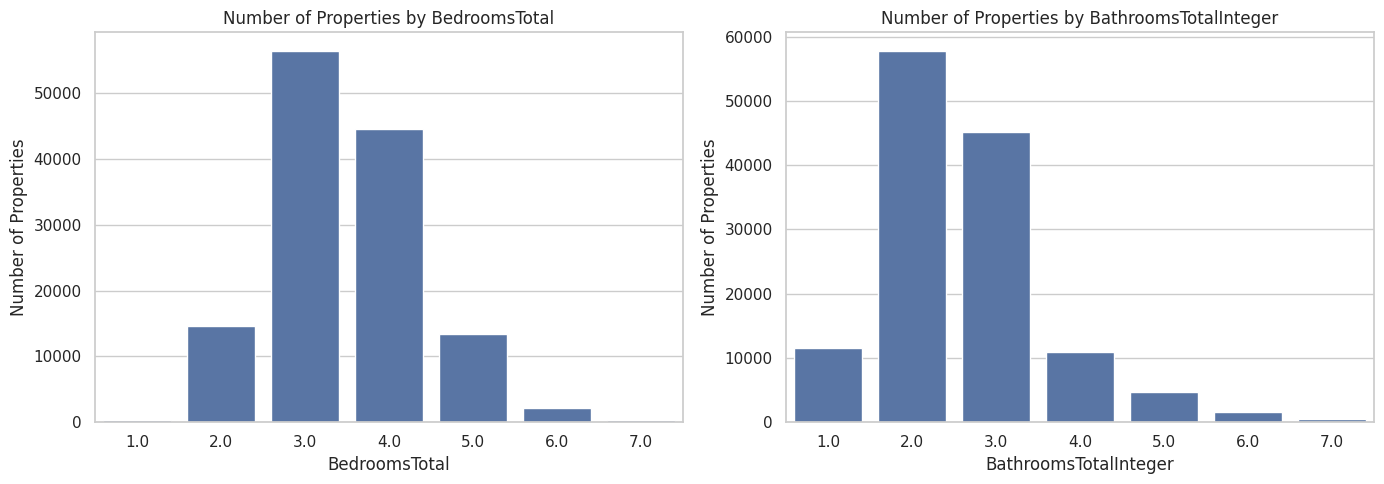

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, predictors_discrete):
    sns.countplot(
        data=df_percentile,
        x=col,
        ax=ax
    )

    ax.set_title(f"Number of Properties by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of Properties")

plt.tight_layout()
plt.show()

### Examine how many 1 and 7 bedroom/bathroom homes were removed by the percentile filtering.

In [55]:
before = df_primary_columns.loc[
    df_primary_columns['BedroomsTotal'] == 1,
    'BedroomsTotal'
].count()

after = df_percentile.loc[
    df_percentile['BedroomsTotal'] == 1,
    'BedroomsTotal'
].count()

print(f"Bedrooms = 1: Before = {before}, After = {after}")

Bedrooms = 1: Before = 838, After = 418


In [56]:
before = df_primary_columns.loc[
    df_primary_columns['BedroomsTotal'] == 7,
    'BedroomsTotal'
].count()

after = df_percentile.loc[
    df_percentile['BedroomsTotal'] == 7,
    'BedroomsTotal'
].count()

print(f"Bedrooms = 7: Before = {before}, After = {after}")

Bedrooms = 7: Before = 487, After = 311


In [57]:
before = df_primary_columns.loc[
    df_primary_columns['BathroomsTotalInteger'] == 1,
    'BathroomsTotalInteger'
].count()

after = df_percentile.loc[
    df_percentile['BathroomsTotalInteger'] == 1,
    'BathroomsTotalInteger'
].count()

print(f"Bathrooms = 1: Before = {before}, After = {after}")

Bathrooms = 1: Before = 12491, After = 11487


In [58]:
before = df_primary_columns.loc[
    df_primary_columns['BathroomsTotalInteger'] == 7,
    'BathroomsTotalInteger'
].count()

after = df_percentile.loc[
    df_percentile['BathroomsTotalInteger'] == 7,
    'BathroomsTotalInteger'
].count()

print(f"Bathrooms = 7: Before = {before}, After = {after}")

Bathrooms = 7: Before = 695, After = 450


The loss of listing with 1 bedroom and bathroom is unnecessary. These features should be filtered by cutoffs, rather than standard deviation or percentiles.

### Scatter Plots of Continuous Predictors vs. Target

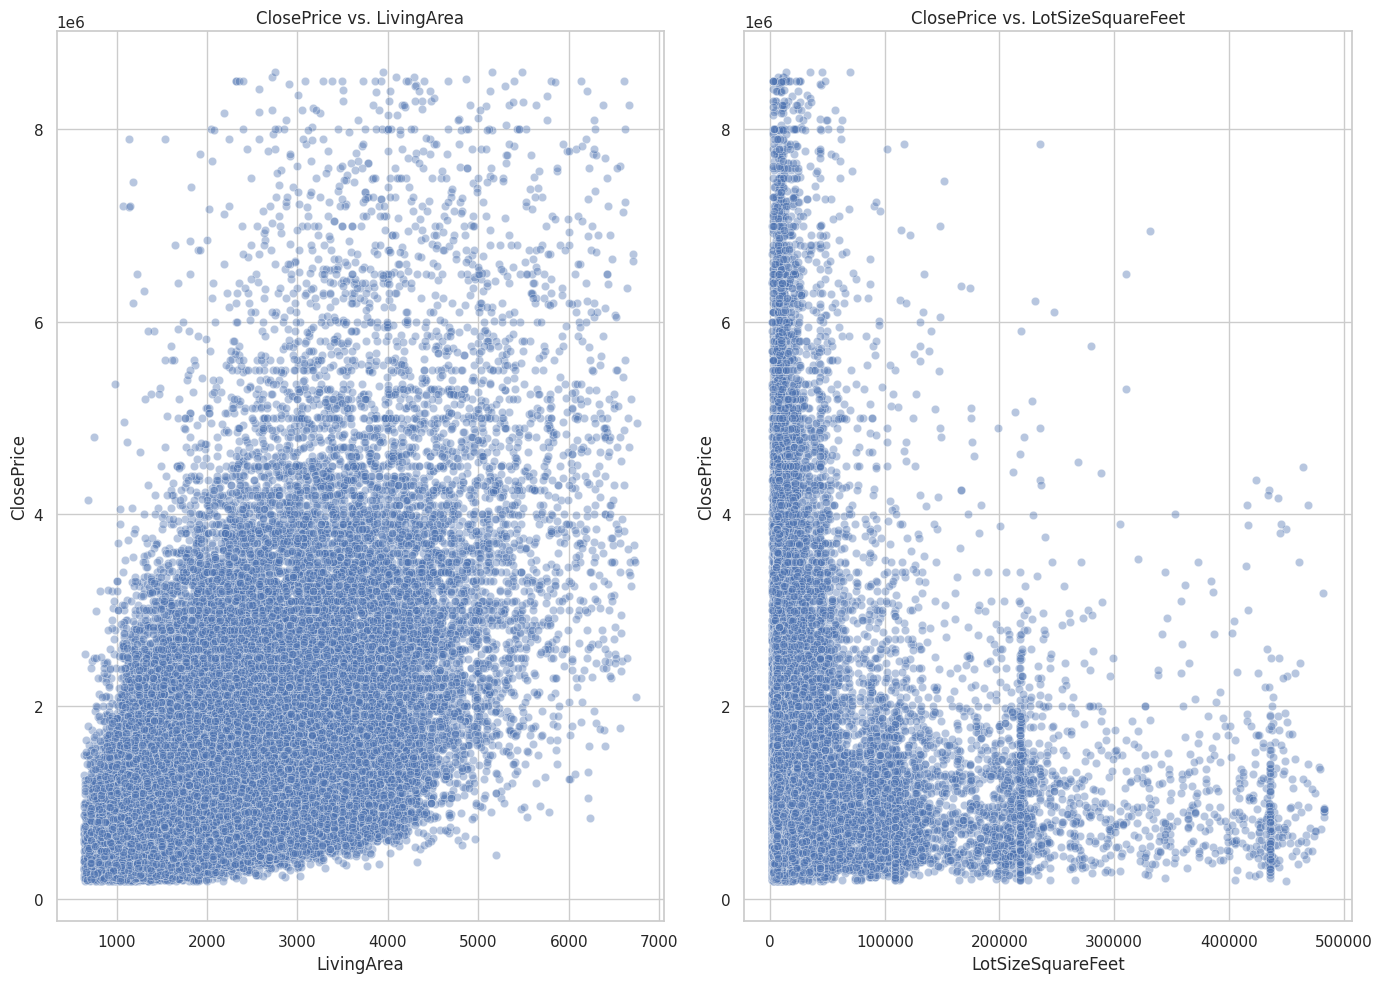

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, predictors_cont):
    sns.scatterplot(
        data=df_percentile,
        x=col,
        y=target,
        alpha=0.4,
        ax=ax
    )

    ax.set_title(f"{target} vs. {col}")
    ax.set_xlabel(col)
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

### Violin plots of Target by Discrete Predictor Value

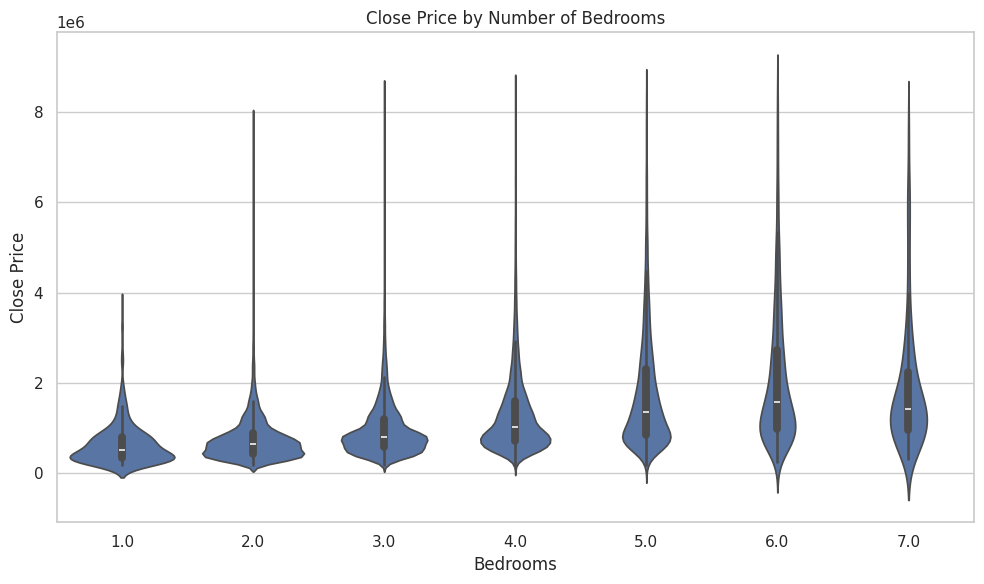

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df_percentile,
    x="BedroomsTotal",
    y="ClosePrice",
    ax=ax
)

ax.set_title("Close Price by Number of Bedrooms")
ax.set_xlabel("Bedrooms")
ax.set_ylabel("Close Price")

plt.tight_layout()
plt.show()

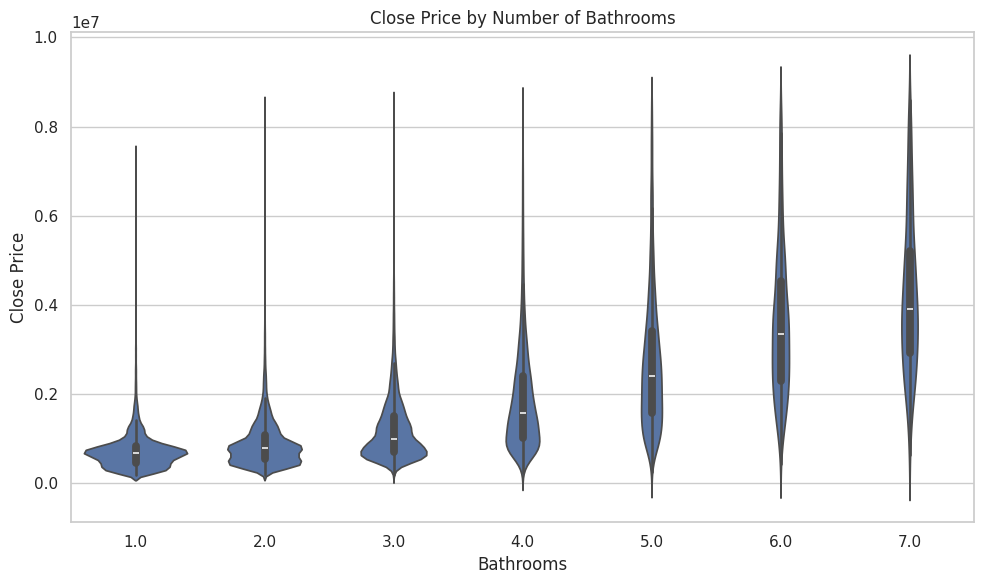

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df_percentile,
    x="BathroomsTotalInteger",
    y="ClosePrice",
    ax=ax
)

ax.set_title("Close Price by Number of Bathrooms")
ax.set_xlabel("Bathrooms")
ax.set_ylabel("Close Price")

plt.tight_layout()
plt.show()

Interestingly, the numner of bathrooms seems to show better correspondence with ClosePrice. We investigate this further below by finding correlation values.

### Heat Map of Correlation Values

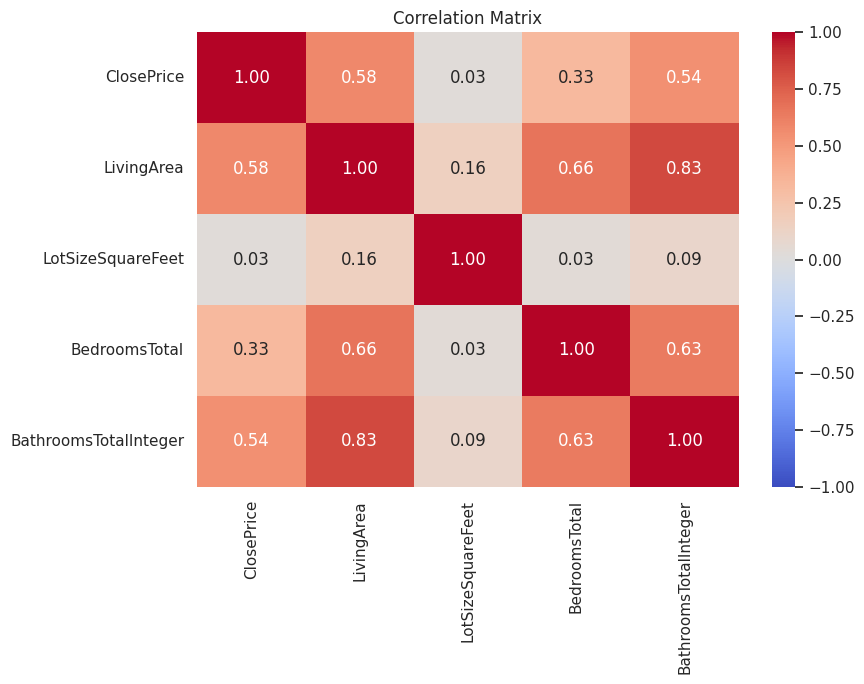

In [62]:
corr = df_percentile[columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The heatmap confirms the difference in correlation seen between ClosePrice and number of bedrooms and numner of bathrooms in the violin plots. But overall the LivingArea has the highest correlation to ClosePrice amongst the primary features.

# Plots Related to CloseDate

### Counts by Month for CloseDate




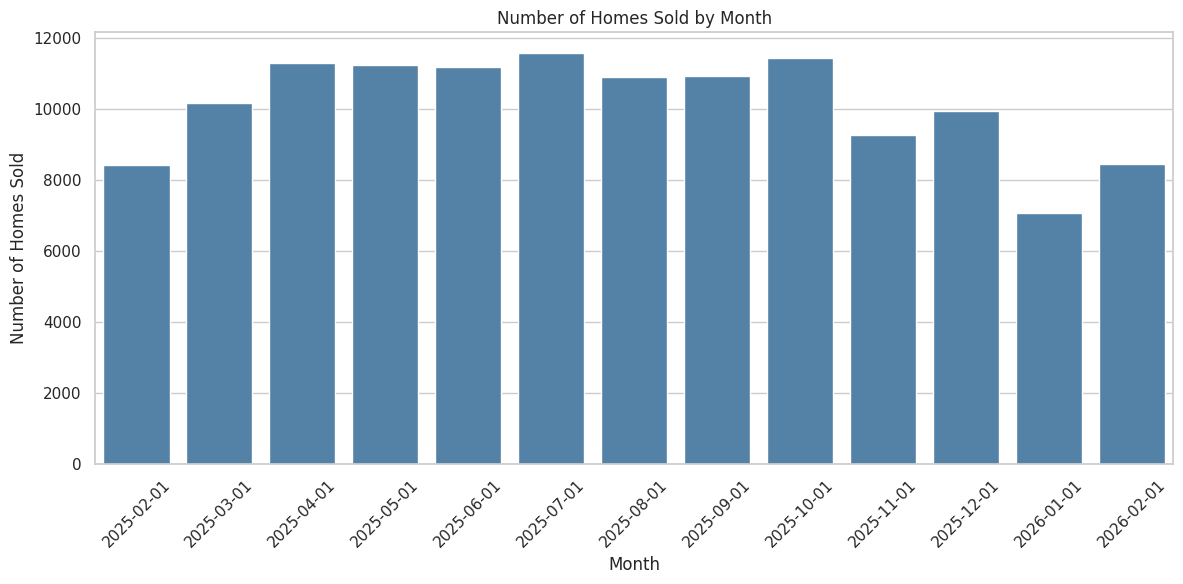

In [63]:
# Create a year-month column
df_percentile["CloseMonth"] = df_percentile["CloseDate"].dt.to_period("M")

# Count sales by month
monthly_sales = (
    df_percentile
    .groupby("CloseMonth")
    .size()
    .reset_index(name="SalesCount")
)

# Convert Period to timestamp for plotting
monthly_sales["CloseMonth"] = monthly_sales["CloseMonth"].dt.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=monthly_sales,
    x="CloseMonth",
    y="SalesCount",
    color="steelblue",
    ax=ax
)

ax.set_title("Number of Homes Sold by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Homes Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Average ClosePrice by Month

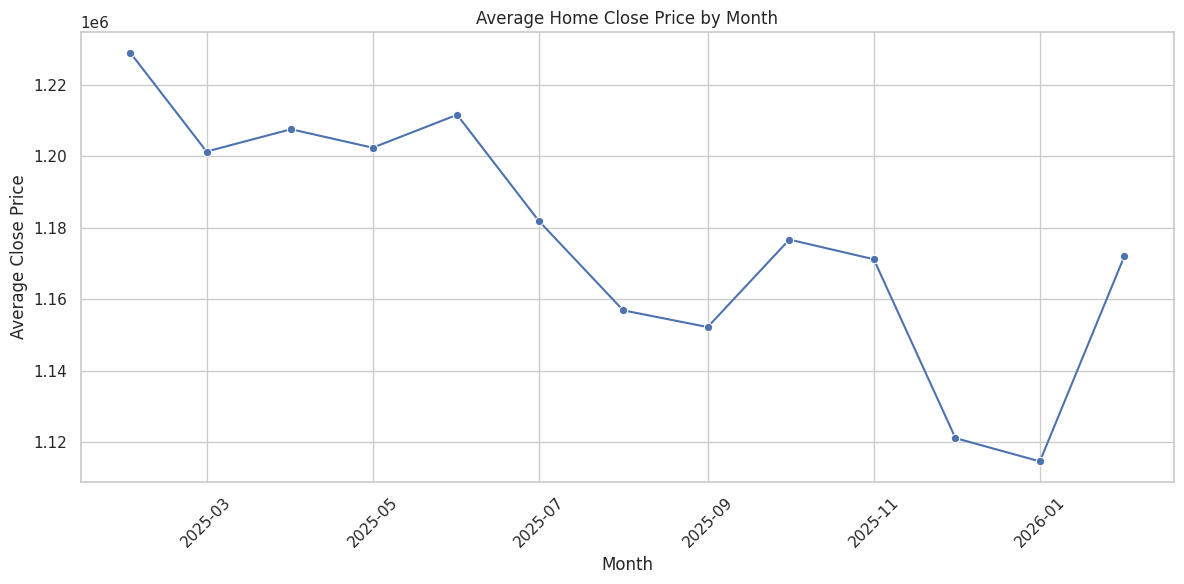

In [64]:
# Calculate average ClosePrice by month
monthly_price = (
    df_percentile
    .groupby('CloseMonth')['ClosePrice']
    .mean()
    .reset_index()
)

# Convert Period to timestamp
monthly_price['CloseMonth'] = monthly_price['CloseMonth'].dt.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=monthly_price,
    x='CloseMonth',
    y='ClosePrice',
    marker='o',
    ax=ax
)

ax.set_title('Average Home Close Price by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Close Price')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()